# LEO Annotations / ScanNet / 3RScan Data Check

Exploratory notebook: peek at LEO's alignment/instruction annotations, cross-reference `scan_id` against local ScanNet `posed_images` and 3RScan `sequence` frames, and attempt a `target_id -> 2D bbox` conversion via `{id}-label.npy`.

**Adjust the path config in the first cell to match your actual cluster layout before running.**

In [1]:
import json, random
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

# --- path config -- adjust these to your actual layout ---
ROOT = Path("/glob/g01-cache/pf/Yushuo/vjepa201")
LEO_ANNO = ROOT / "source_data/leo_annotations/annotations"
SCANNET_POSED = Path("/glob/g01-cache/pf/Yushuo/vjepa201/source_data/scannet/posed_images")  # TODO: confirm this matches your scannet mount
THREERSCAN_ROOT = ROOT / "source_data/3rscan"

def load_json(p):
    with open(p, encoding="utf-8") as f:
        return json.load(f)


## 1. LEO annotations -- random instance peek

Loads the ScanNet-anchored + 3RScan-anchored annotation files and prints a couple random rows from each so you can eyeball the schema.

In [2]:
FILES = {
    "scanrefer_train":  LEO_ANNO / "instruction/scan2cap/scanrefer_train.json",
    "nr3d":             LEO_ANNO / "alignment/obj_scene_caption/scannet_referit3d_nr3d_train.json",
    "sr3d+":            LEO_ANNO / "alignment/obj_scene_caption/scannet_referit3d_sr3d+_train.json",
    "3rscan_scenecap":  LEO_ANNO / "alignment/scene_caption/3rscan_scenecap_train.json",
}

loaded = {}
for name, path in FILES.items():
    if not path.exists():
        print(f"[skip] {name}: not found at {path}")
        continue
    data = load_json(path)
    loaded[name] = data
    kind = "list" if isinstance(data, list) else "dict (keyed by scan_id)"
    print(f"{name}: {len(data)} entries, {kind}")


scanrefer_train: 36665 entries, list
nr3d: 30037 entries, list
sr3d+: 90450 entries, list
3rscan_scenecap: 1178 entries, dict (keyed by scan_id)


In [4]:
def _print_row(row, skip_keys=("query", "tokens", "enc_tokens")):
 """Print all fields in full except the long/uninteresting ones (query is
 just the LLM prompt used to generate `response`, tokens/enc_tokens are
 leftover tokenization from LEO's own model -- not useful here)."""
 for k, v in row.items():
     if k in skip_keys:
         print(f"  {k}: <skipped, len={len(str(v))}>")
     else:
         print(f"  {k}: {v}")

for name, data in loaded.items():
 print(f"\n=== {name} ===")
 if isinstance(data, list):
     for row in random.sample(data, min(3, len(data))):
         _print_row(row)
         print("---")
 else:  # dict keyed by scan_id (3rscan_scenecap)
     for scan_id in random.sample(list(data.keys()), min(2, len(data))):
         entries = data[scan_id]
         print(f"scan_id={scan_id}, {len(entries)} caption variants (different ratio/random_id)")
         _print_row(random.choice(entries))
         print("---")


=== scanrefer_train ===
  item_id: scanrefer_train_003782
  scan_id: scene0066_00
  target_id: 5
  instance_type: office chair
  utterance: this is a cushion chair with arm. the chair is in the bottom left corner.
  tokens: <skipped, len=127>
  enc_tokens: <skipped, len=113>
  ann_id: 2
---
  item_id: scanrefer_train_035869
  scan_id: scene0680_00
  target_id: 11
  instance_type: door
  utterance: there is a door with a window in it on the right side of the back wall of the room. it touches the corner of the room and is on the right side of the windows.
  tokens: <skipped, len=275>
  enc_tokens: <skipped, len=239>
  ann_id: 1
---
  item_id: scanrefer_train_021039
  scan_id: scene0402_00
  target_id: 11
  instance_type: trash can
  utterance: it is a black trash can on the floor. it is sitting against the red wall.
  tokens: <skipped, len=130>
  enc_tokens: <skipped, len=119>
  ann_id: 0
---

=== nr3d ===
  item_id: nr3d_016628
  stimulus_id: scene0386_00-couch-2-3-2
  scan_id: scene03

## 2. Cross-reference with ScanNet / 3RScan -- locate frames + visualize

`scan_id` in ScanRefer/Nr3D/Sr3D+ rows is a ScanNet id (`sceneXXXX_XX`) -> look up `SCANNET_POSED/<scan_id>/`.
`scan_id` in `3rscan_scenecap` is a 3RScan UUID -> look up `THREERSCAN_ROOT/<scan_id>/sequence/`.

In [11]:
def scannet_frames(scan_id, root=SCANNET_POSED):
  scene_dir = root / scan_id
  if not scene_dir.exists():
      return []
  return sorted(
      p for p in scene_dir.glob("*.jpg")
      if "-annotated" not in p.stem
  )

def rscan_frames(scan_id, root=THREERSCAN_ROOT):
    seq_dir = root / scan_id / "sequence"
    if not seq_dir.exists():
        return []
    # 3RScan sequence.zip layout not yet confirmed -- if this returns nothing,
    # run `list(seq_dir.glob("*"))[:20]` to see actual filenames and fix the pattern.
    return sorted(seq_dir.glob("*color*"))


scan_id=scene0539_00  target_id=12
utterance: this is a white door to the house. it is next to the blue flowers.
found 502 posed_images frames for this scene


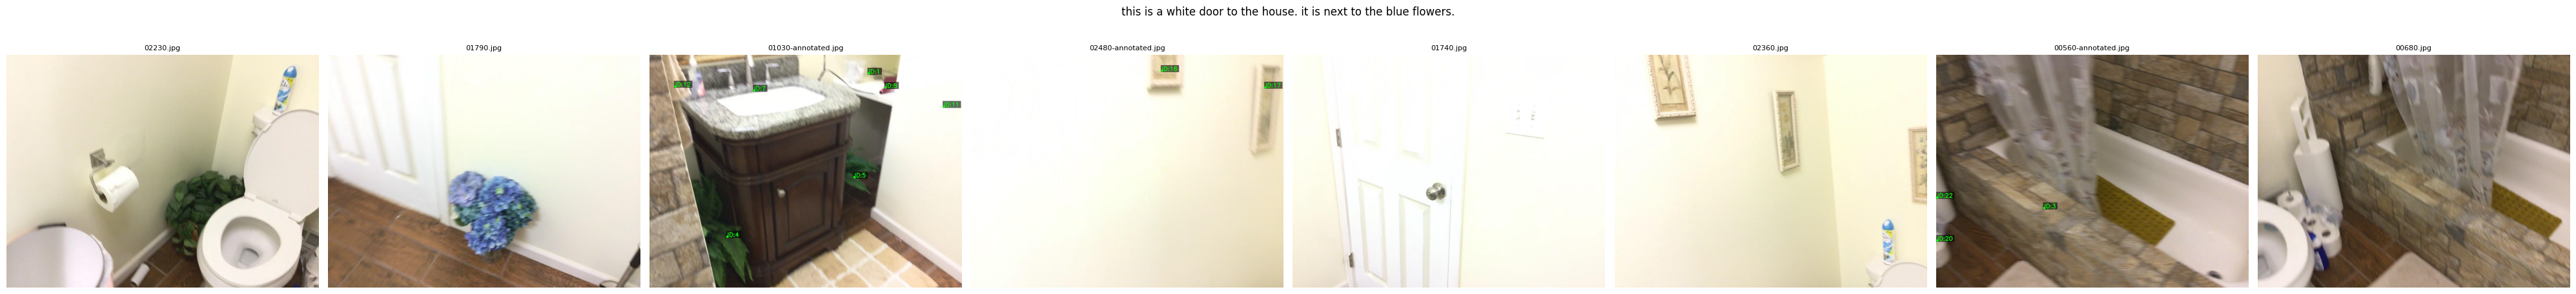

In [7]:
# --- ScanNet-anchored example (ScanRefer) ---
row = random.choice(loaded["scanrefer_train"])
scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
print(f"scan_id={scan_id}  target_id={target_id}")
print(f"utterance: {utterance}")

frames = scannet_frames(scan_id)
print(f"found {len(frames)} posed_images frames for this scene")

sample_frames = random.sample(frames, min(8, len(frames))) if frames else []
if sample_frames:
    fig, axes = plt.subplots(1, len(sample_frames), figsize=(5 * len(sample_frames), 5))
    if len(sample_frames) == 1:
        axes = [axes]
    for ax, fp in zip(axes, sample_frames):
        ax.imshow(Image.open(fp).convert("RGB"))
        ax.set_title(fp.name, fontsize=8)
        ax.axis("off")
    plt.suptitle(utterance[:80])
    plt.tight_layout()
    plt.show()
else:
    print("no frames found -- check SCANNET_POSED path / scan_id naming")


scan_id=ad408c99-84db-2095-8b23-0a011526b47b
response: In the room, there is a tall radiator. A simple stool stands in front of a red, narrow, and messy bed. The stool is also to the left of a commode. A colorful, flat picture is in front of a big plant. A big, flat picture is lying on the floor, to the right of the bed, and behind a cabinet. Blankets a
found 183 frames via rscan_frames() pattern


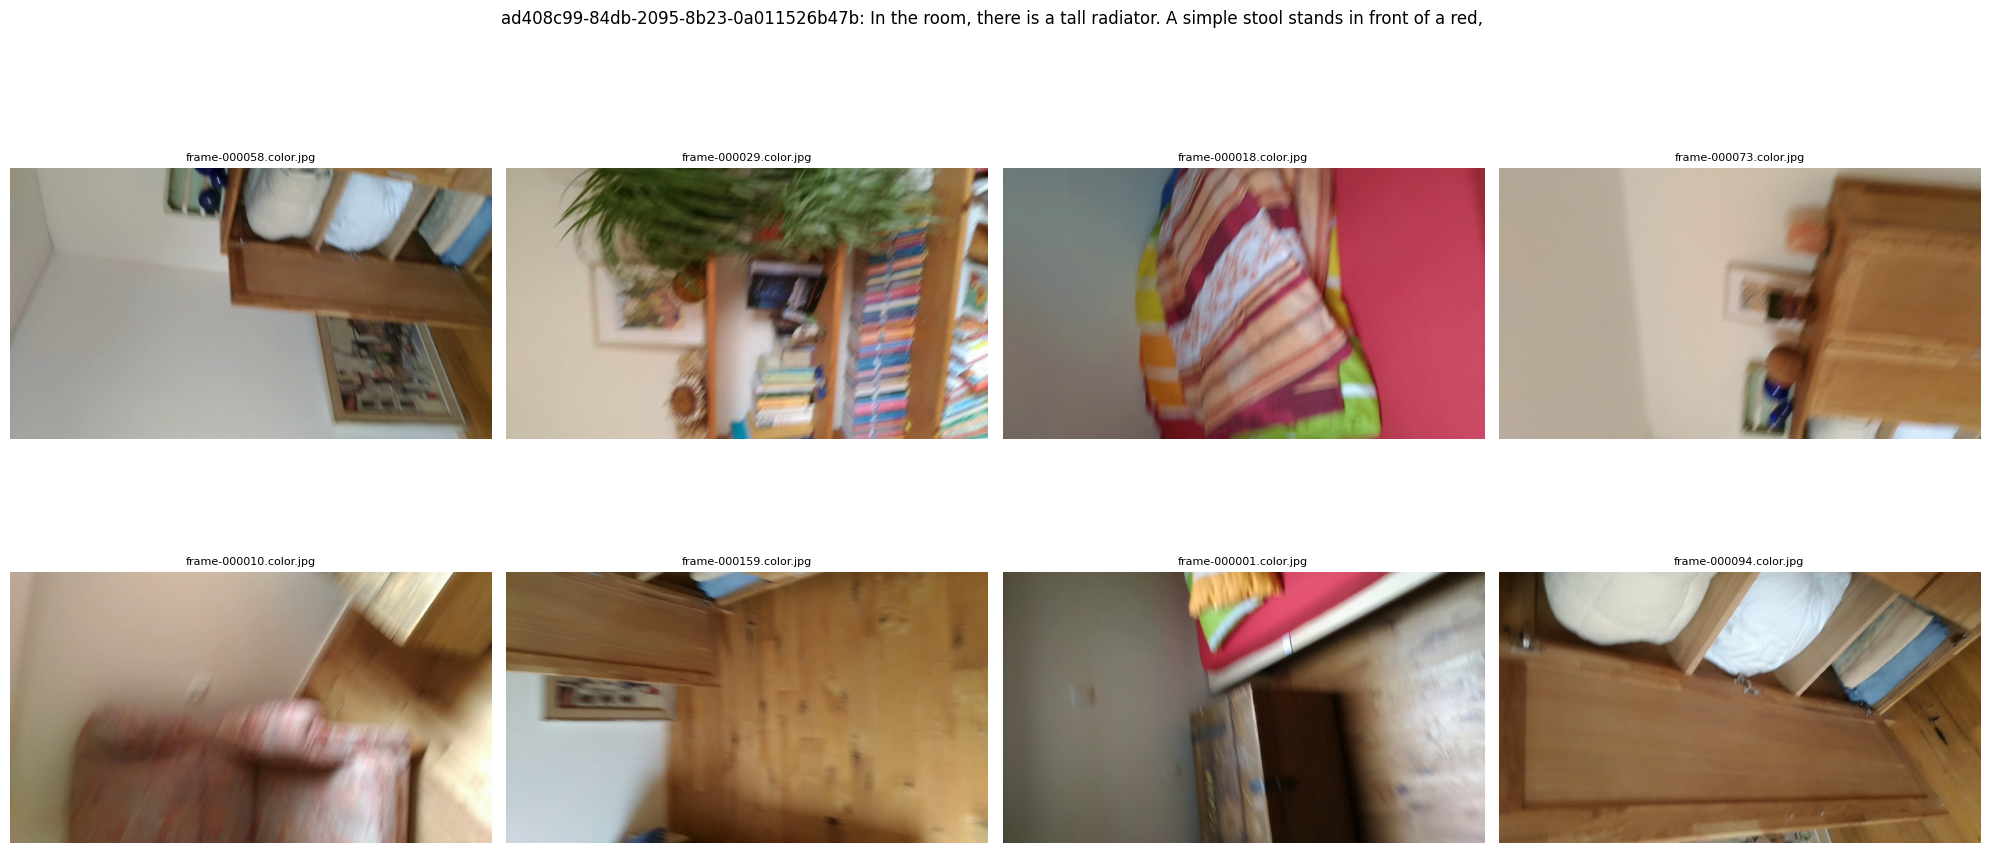

In [9]:
scan_id = random.choice(list(loaded["3rscan_scenecap"].keys()))
entry = random.choice(loaded["3rscan_scenecap"][scan_id])
print(f"scan_id={scan_id}")
print("response:", entry["response"][:300])

frames = rscan_frames(scan_id)
print(f"found {len(frames)} frames via rscan_frames() pattern")

seq_dir = THREERSCAN_ROOT / scan_id / "sequence"
if not frames and seq_dir.exists():
  print("pattern matched nothing -- actual files in sequence/:")
  print(list(seq_dir.glob("*"))[:20])
elif frames:
  sample_frames = random.sample(frames, min(8, len(frames)))
  n_cols = 4
  n_rows = 2
  fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows))
  axes = axes.flatten()
  for ax, fp in zip(axes, sample_frames):
      ax.imshow(Image.open(fp).convert("RGB"))
      ax.set_title(fp.name, fontsize=8)
      ax.axis("off")
  for ax in axes[len(sample_frames):]:
      ax.axis("off")
  plt.suptitle(f"{scan_id}: {entry['response'][:80]}")
  plt.tight_layout()
  plt.show()


## 3. bbox conversion attempt -- `target_id` -> 2D box via `{id}-label.npy`

First inspect the raw label map format (unconfirmed: could be per-pixel instance IDs, or something else -- semantic class ids, etc). Don't trust the extraction below until this cell's output makes sense.

In [14]:
row = random.choice(loaded["scanrefer_train"])
scan_id, target_id = row["scan_id"], row["target_id"]
frames = scannet_frames(scan_id)

if frames:
    label_path = frames[0].with_name(frames[0].stem + "-label.npy")
    if label_path.exists():
        label = np.load(label_path)
        print("label.npy shape:", label.shape, "dtype:", label.dtype)
        print("unique values (first 20):", np.unique(label)[:20])
        print(f"this row's target_id = {target_id} -- is it among the unique values above?")
    else:
        print(f"no label.npy next to {frames[0].name} -- check the naming convention (expected '{frames[0].stem}-label.npy')")
else:
    print(f"no frames found for {scan_id}")


label.npy shape: (968, 1296) dtype: uint8
unique values (first 20): [ 0  1  4  5  6  8  9 11 13 17 18]
this row's target_id = 29 -- is it among the unique values above?


In [15]:
scan_id = row["scan_id"]  # 用同一个scan_id, 别换
frames = scannet_frames(scan_id)
all_values = set()
for fp in frames:
  label_path = fp.with_name(fp.stem + "-label.npy")
  if label_path.exists():
      all_values |= set(np.unique(np.load(label_path)).tolist())

print(f"全场景{len(frames)}帧, 一共出现过{len(all_values)}个不同的label值")
print(f"target_id={target_id} 在不在里面: {target_id in all_values}")

全场景128帧, 一共出现过26个不同的label值
target_id=29 在不在里面: False


In [22]:

npz_path = frames[0].with_name(frames[0].stem + "-overlap.npz")
data = np.load(npz_path, allow_pickle=True)
print("keys:", data.files)

indices = data["indices"]
box_lists = data["box_lists"]
print("indices:", indices.shape, indices.dtype)
print("box_lists type:", type(box_lists), "shape:", box_lists.shape if hasattr(box_lists,
"shape") else len(box_lists))

# box_lists大概率是object数组, 逐个元素看结构
print(box_lists[0])
print(box_lists[:3])
scan_id = row["scan_id"]
frames = scannet_frames(scan_id)
all_values = set()
for fp in frames:
  npz_path = fp.with_name(fp.stem + "-overlap.npz")
  if npz_path.exists():
      d = np.load(npz_path, allow_pickle=True)
      for entry in d["box_lists"]:
          all_values.update(entry)

print(f"全场景{len(frames)}帧, overlap.npz里一共出现过{len(all_values)}个不同的值")
print(f"target_id={target_id} 在不在里面: {target_id in all_values}")

keys: ['indices', 'box_lists']
indices: (209428, 2) int32
box_lists type: <class 'numpy.ndarray'> shape: (209428,)
[13, 6]
[list([13, 6]) list([13, 6]) list([13, 6])]
全场景128帧, overlap.npz里一共出现过22个不同的值
target_id=29 在不在里面: False


In [ ]:
def target_bbox_in_frame(frame_path, target_id):
    """Best-effort: assumes {id}-label.npy is a per-pixel instance-id map
    whose values line up with ScanRefer/Nr3D/Sr3D+ target_id numbering.
    Verify against the cell above first -- if the assumption is wrong (e.g.
    semantic classes instead of instances), this silently returns None for
    everything, or matches the wrong region.
    """
    label_path = frame_path.with_name(frame_path.stem + "-label.npy")
    if not label_path.exists():
        return None
    label = np.load(label_path)
    ys, xs = np.where(label == target_id)
    if len(xs) == 0:
        return None
    return [int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())]


row = random.choice(loaded["scanrefer_train"])
scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
frames = scannet_frames(scan_id)

found = None
for fp in frames:
    box = target_bbox_in_frame(fp, target_id)
    if box is not None:
        found = (fp, box)
        break

if found is None:
    print(f"target_id={target_id} not found in any sampled frame for {scan_id} -- "
          f"could be normal (object not visible in this scene's posed_images subsample), "
          f"or label.npy isn't instance-indexed the way assumed above. Try a different row "
          f"or re-run the cell (random row each time) if this keeps happening.")
else:
    fp, box = found
    print(f"found in {fp.name}, box={box}")
    img = Image.open(fp).convert("RGB")
    draw = ImageDraw.Draw(img)
    draw.rectangle(box, outline="red", width=3)
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.title(utterance[:80])
    plt.axis("off")
    plt.show()


In [ ]:
# Retry a few times if the random row above missed -- quick loop to find one that hits.
for _ in range(20):
    row = random.choice(loaded["scanrefer_train"])
    scan_id, target_id, utterance = row["scan_id"], row["target_id"], row["utterance"]
    frames = scannet_frames(scan_id)
    hit = None
    for fp in frames:
        box = target_bbox_in_frame(fp, target_id)
        if box is not None:
            hit = (fp, box)
            break
    if hit:
        fp, box = hit
        print(f"scan_id={scan_id} target_id={target_id} -> {fp.name} box={box}")
        img = Image.open(fp).convert("RGB")
        draw = ImageDraw.Draw(img)
        draw.rectangle(box, outline="lime", width=3)
        plt.figure(figsize=(6, 6))
        plt.imshow(img)
        plt.title(utterance[:80])
        plt.axis("off")
        plt.show()
        break
else:
    print("no hit in 20 tries -- worth revisiting the label.npy format assumption in section 3's first cell.")
